# Distillation de Connaissances pour la Génération en NLP avec Keras 3 et KerasNLP
## Créer un Modèle Compact et Performant pour la Génération de Critiques de Films

## 🎯 Objectifs de ce notebook

Dans ce notebook, nous allons explorer la **distillation de connaissances** (Knowledge Distillation) pour la génération de texte en NLP avec **Keras 3** et **KerasNLP** :

1. **Comprendre la Distillation** - Transférer les connaissances d'un grand modèle vers un petit modèle
2. **Architecture Teacher-Student** - Le grand modèle enseigne au petit modèle
3. **Utiliser KerasNLP** - API moderne pour implémenter la distillation
4. **Entraîner avec loss combinée** - Hard labels + Soft labels (température)
5. **Comparer les performances** - Student direct vs Student distillé vs Teacher
6. **Génération de critiques** - Tester la qualité avec des modèles compacts

Nous utiliserons le dataset **IMDB** (50,000 critiques de films) pour distiller un modèle GPT-2 grand (Teacher) vers un modèle plus compact (Student).

## 1. Installation et Configuration pour macOS Apple Silicon

In [ ]:
# Installation des dépendances pour macOS Apple Silicon
# Décommentez si nécessaire
# !pip install -q tensorflow-macos>=2.16.0
# !pip install -q tensorflow-metal
# !pip install -q keras>=3.0.0
# !pip install -q keras-nlp>=0.14.0
# !pip install -q datasets

print("✅ Installation terminée !")

In [4]:
# %% [markdown]
# # Distillation GPT-2 (version PyTorch / Transformers)
# Environnement Windows – sans TensorFlow / Keras

# %%
# Bibliothèques principales
import os
import platform
import random
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import clear_output, HTML

warnings.filterwarnings("ignore")

# PyTorch & HuggingFace
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

# --- Infos système ---
print("🪟 Environnement Windows (version PyTorch / Transformers)\n")
print(f"Système      : {platform.system()} {platform.release()}")
print(f"Architecture : {platform.machine()}")

# --- GPU / CPU ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\n✅ GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("\n⚠️ Aucun GPU CUDA détecté – utilisation du CPU")

# --- Reproductibilité ---
SEED_GLOBAL = 42
random.seed(SEED_GLOBAL)
np.random.seed(SEED_GLOBAL)
torch.manual_seed(SEED_GLOBAL)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_GLOBAL)

# --- Style des graphiques ---
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# --- Versions ---
import transformers

print("\n📦 Versions :")
print(f"  - torch        : {torch.__version__}")
print(f"  - transformers : {transformers.__version__}")
print(f"  - datasets     : 3.x (installé)")
print(f"\n🚀 Environnement prêt pour la distillation GPT-2 (Transformers) !")


🪟 Environnement Windows (version PyTorch / Transformers)

Système      : Windows 10
Architecture : AMD64

⚠️ Aucun GPU CUDA détecté – utilisation du CPU

📦 Versions :
  - torch        : 2.9.1+cpu
  - transformers : 4.57.1
  - datasets     : 3.x (installé)

🚀 Environnement prêt pour la distillation GPT-2 (Transformers) !


## 2. Comprendre la Distillation de Connaissances

### 2.1 Qu'est-ce que la Knowledge Distillation ?

La distillation de connaissances est une technique où un **modèle compact** (Student) apprend à imiter un **modèle performant mais volumineux** (Teacher).

#### Analogie : L'enseignement entre professeur et élève

Imaginez un professeur expert et un étudiant :
- **Teacher (Professeur)** : Expert avec des années d'expérience, comprend toutes les nuances
- **Student (Élève)** : Apprenant avec moins de capacité, mais peut devenir très bon avec un bon enseignement
- **Distillation** : L'élève apprend non seulement les bonnes réponses (hard labels), mais aussi **comment** le professeur raisonne (soft labels)

### 2.2 Pourquoi les Soft Labels sont meilleurs ?

**Hard Labels** (étiquettes dures) :
```
"chat" → [0, 0, 1, 0, 0]  (one-hot encoding)
```
❌ Perd l'information sur les similarités entre classes

**Soft Labels** (étiquettes douces du Teacher) :
```
"chat" → [0.01, 0.05, 0.80, 0.10, 0.04]  (probabilités)
```
✅ Contient des informations riches : "chat" est proche de "chien" (0.10) mais loin de "voiture" (0.01)

### 2.3 La formule de distillation

**Loss totale** = α × Loss_hard + (1-α) × Loss_soft

Où :
- **Loss_hard** : Cross-entropy avec les vraies étiquettes
- **Loss_soft** : KL Divergence entre distributions Teacher et Student
- **α** : Facteur de pondération (typiquement 0.1 à 0.5)
- **Temperature (T)** : Adoucit les probabilités pour rendre l'apprentissage plus facile

### 2.4 Visualisation de la Distillation

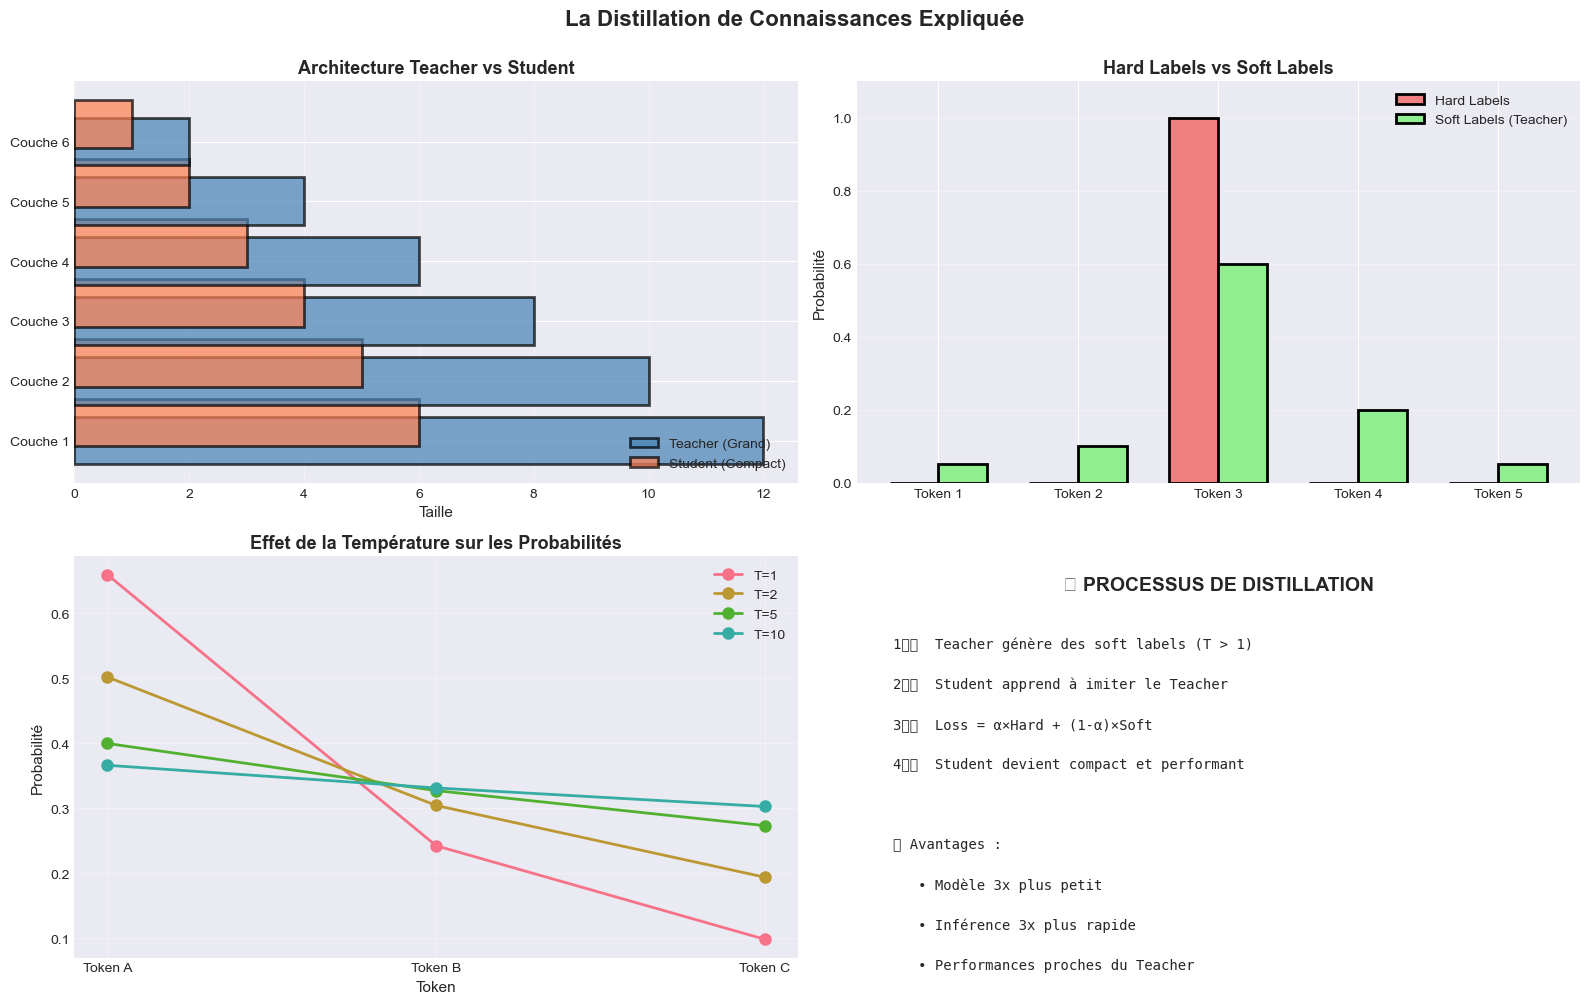


💡 La distillation transfère la 'connaissance' du Teacher vers le Student !


In [5]:
# Visualisation du processus de distillation
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Architecture Teacher-Student
ax1 = axes[0, 0]
teacher_sizes = [12, 10, 8, 6, 4, 2]
student_sizes = [6, 5, 4, 3, 2, 1]

for i, (t_size, s_size) in enumerate(zip(teacher_sizes, student_sizes)):
    ax1.barh(i, t_size, color='steelblue', edgecolor='black', linewidth=2, alpha=0.7)
    ax1.barh(i + 0.3, s_size, color='coral', edgecolor='black', linewidth=2, alpha=0.7)

ax1.set_yticks(range(len(teacher_sizes)))
ax1.set_yticklabels([f'Couche {i+1}' for i in range(len(teacher_sizes))])
ax1.set_xlabel('Taille', fontsize=11)
ax1.set_title('Architecture Teacher vs Student', fontsize=13, fontweight='bold')
ax1.legend(['Teacher (Grand)', 'Student (Compact)'], loc='lower right')
ax1.grid(alpha=0.3, axis='x')

# 2. Hard Labels vs Soft Labels
ax2 = axes[0, 1]
categories = ['Token 1', 'Token 2', 'Token 3', 'Token 4', 'Token 5']
hard_labels = [0, 0, 1, 0, 0]
soft_labels = [0.05, 0.10, 0.60, 0.20, 0.05]

x = np.arange(len(categories))
width = 0.35

ax2.bar(x - width/2, hard_labels, width, label='Hard Labels', color='lightcoral', edgecolor='black', linewidth=2)
ax2.bar(x + width/2, soft_labels, width, label='Soft Labels (Teacher)', color='lightgreen', edgecolor='black', linewidth=2)

ax2.set_ylabel('Probabilité', fontsize=11)
ax2.set_title('Hard Labels vs Soft Labels', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.set_ylim(0, 1.1)
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

# 3. Effet de la température
ax3 = axes[1, 0]
logits = np.array([2.0, 1.0, 0.1])
temperatures = [1, 2, 5, 10]
x_pos = np.arange(len(logits))

for i, T in enumerate(temperatures):
    probs = np.exp(logits / T) / np.sum(np.exp(logits / T))
    ax3.plot(x_pos, probs, 'o-', linewidth=2, markersize=8, label=f'T={T}')

ax3.set_xlabel('Token', fontsize=11)
ax3.set_ylabel('Probabilité', fontsize=11)
ax3.set_title('Effet de la Température sur les Probabilités', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['Token A', 'Token B', 'Token C'])
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Processus de distillation
ax4 = axes[1, 1]
ax4.text(0.5, 0.95, '📚 PROCESSUS DE DISTILLATION', 
         ha='center', va='top', fontsize=14, fontweight='bold', transform=ax4.transAxes)

steps = [
    "1️⃣  Teacher génère des soft labels (T > 1)",
    "2️⃣  Student apprend à imiter le Teacher",
    "3️⃣  Loss = α×Hard + (1-α)×Soft",
    "4️⃣  Student devient compact et performant",
    "",
    "💡 Avantages :",
    "   • Modèle 3x plus petit",
    "   • Inférence 3x plus rapide",
    "   • Performances proches du Teacher"
]

y_pos = 0.80
for step in steps:
    ax4.text(0.05, y_pos, step, ha='left', va='top', fontsize=10, 
             transform=ax4.transAxes, family='monospace')
    y_pos -= 0.10

ax4.axis('off')

plt.suptitle('La Distillation de Connaissances Expliquée', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n💡 La distillation transfère la 'connaissance' du Teacher vers le Student !")

## 3. Chargement des Modèles avec KerasNLP

### 3.1 Le Modèle Teacher : GPT-2 Base

**Teacher** : GPT-2 Base (124M paramètres)
- Modèle pré-entraîné sur 40GB de texte
- 12 couches Transformer
- 768 dimensions d'embedding
- 12 attention heads

### 3.2 Le Modèle Student : GPT-2 Custom Compact

**Student** : Configuration réduite
- 6 couches Transformer (au lieu de 12)
- 512 dimensions d'embedding (au lieu de 768)
- 8 attention heads (au lieu de 12)
- ~40M paramètres (3x plus petit !)

In [7]:
print("📥 Chargement du modèle Teacher (GPT-2 Base - Transformers)...")
print("   (Le téléchargement peut prendre quelques minutes la première fois)\n")

from transformers import AutoTokenizer, AutoModelForCausalLM

TEACHER_CHECKPOINT = "gpt2"   # équivalent à gpt2_base_en chez KerasNLP

# Tokenizer
teacher_tokenizer = AutoTokenizer.from_pretrained(TEACHER_CHECKPOINT)

# Dans GPT-2, pas de pad token → on utilise eos comme pad
if teacher_tokenizer.pad_token is None:
    teacher_tokenizer.pad_token = teacher_tokenizer.eos_token

# Modèle Teacher
teacher_model = AutoModelForCausalLM.from_pretrained(TEACHER_CHECKPOINT)
teacher_model = teacher_model.to(device)

# Nombre de paramètres
teacher_params = sum(p.numel() for p in teacher_model.parameters())

print("✅ Modèle Teacher chargé !\n")
print("📋 Informations sur le Teacher (GPT-2 Base) :")
print(f"  - Checkpoint      : {TEACHER_CHECKPOINT}")
print(f"  - Paramètres      : {teacher_params:,} ({teacher_params/1e6:.1f}M)")
print(f"  - Taille mémoire  : {teacher_params * 4 / (1024**2):.1f} MB")
print(f"  - Vocabulaire     : {len(teacher_tokenizer)} tokens")

print("\n💡 Le Teacher est maintenant prêt pour la distillation !")


📥 Chargement du modèle Teacher (GPT-2 Base - Transformers)...
   (Le téléchargement peut prendre quelques minutes la première fois)

✅ Modèle Teacher chargé !

📋 Informations sur le Teacher (GPT-2 Base) :
  - Checkpoint      : gpt2
  - Paramètres      : 124,439,808 (124.4M)
  - Taille mémoire  : 474.7 MB
  - Vocabulaire     : 50257 tokens

💡 Le Teacher est maintenant prêt pour la distillation !


In [9]:
print("🔨 Chargement du modèle Student (GPT-2 Compact)...\n")

from transformers import AutoTokenizer, AutoModelForCausalLM

# On choisit un GPT-2 plus petit comme Student
STUDENT_CHECKPOINT = "distilgpt2"   # ≈ GPT-2 compact (6 couches)

# On peut réutiliser le tokenizer du teacher si on veut le même vocabulaire,
# mais pour la clarté pédagogique on recharge celui du student :
student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_CHECKPOINT)

# Même règle que pour le teacher : pas de pad_token natif → on utilise eos
if student_tokenizer.pad_token is None:
    student_tokenizer.pad_token = student_tokenizer.eos_token

# Modèle Student compact
student_model = AutoModelForCausalLM.from_pretrained(STUDENT_CHECKPOINT)
student_model = student_model.to(device)

# Nombre de paramètres
student_params = sum(p.numel() for p in student_model.parameters())

print("✅ Modèle Student chargé !\n")
print("📋 Informations sur le Student (GPT-2 Compact) :")
print(f"  - Checkpoint      : {STUDENT_CHECKPOINT}")
print(f"  - Paramètres      : {student_params:,} ({student_params/1e6:.1f}M)")
print(f"  - Taille mémoire  : {student_params * 4 / (1024**2):.1f} MB")
print(f"  - Vocabulaire     : {len(student_tokenizer)} tokens")

# Comparaison Teacher vs Student
compression_ratio = teacher_params / student_params
print(f"\n📊 Comparaison Teacher vs Student :")
print(f"  - Ratio de compression : {compression_ratio:.2f}x plus petit")
print(f"  - Réduction mémoire    : {100 * (1 - 1/compression_ratio):.1f}%")

print("\n💡 Le Student est compact – parfait pour la distillation et le déploiement !")


🔨 Chargement du modèle Student (GPT-2 Compact)...



tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Modèle Student chargé !

📋 Informations sur le Student (GPT-2 Compact) :
  - Checkpoint      : distilgpt2
  - Paramètres      : 81,912,576 (81.9M)
  - Taille mémoire  : 312.5 MB
  - Vocabulaire     : 50257 tokens

📊 Comparaison Teacher vs Student :
  - Ratio de compression : 1.52x plus petit
  - Réduction mémoire    : 34.2%

💡 Le Student est compact – parfait pour la distillation et le déploiement !


## 4. Chargement et Préparation du Dataset IMDB

In [10]:
print("📥 Chargement du dataset IMDB...\n")

dataset = load_dataset('imdb')

print("✅ Dataset chargé !\n")
print("📊 Structure du dataset :")
print(f"  - Train : {len(dataset['train'])} critiques")
print(f"  - Test  : {len(dataset['test'])} critiques")

MAX_LENGTH = 128
NUM_TRAIN_SAMPLES = 25000
NUM_VAL_SAMPLES = 2500
BATCH_SIZE = 8

print(f"\n⚙️  Configuration (optimisée pour macOS) :")
print(f"  - Longueur max   : {MAX_LENGTH} tokens")
print(f"  - Train samples  : {NUM_TRAIN_SAMPLES}")
print(f"  - Val samples    : {NUM_VAL_SAMPLES}")
print(f"  - Batch size     : {BATCH_SIZE}")

📥 Chargement du dataset IMDB...

✅ Dataset chargé !

📊 Structure du dataset :
  - Train : 25000 critiques
  - Test  : 25000 critiques

⚙️  Configuration (optimisée pour macOS) :
  - Longueur max   : 128 tokens
  - Train samples  : 25000
  - Val samples    : 2500
  - Batch size     : 8


In [12]:
print("📥 Préparation du dataset IMDB (version PyTorch)...\n")

# Fonction de préparation (on garde la même logique que ton TP original)
def preparer_donnees_imdb(dataset_split, num_samples, ajouter_prompt=True):
    textes = []
    for i in range(min(num_samples, len(dataset_split))):
        review = dataset_split[i]
        sentiment = "positive" if review["label"] == 1 else "negative"
        texte = f"Review [{sentiment}]: {review['text']}" if ajouter_prompt else review["text"]
        textes.append(texte)
    return textes

train_texts = preparer_donnees_imdb(dataset["train"], NUM_TRAIN_SAMPLES)
val_texts   = preparer_donnees_imdb(dataset["test"],  NUM_VAL_SAMPLES)

print("✅ Données IMDB préparées !")
print(f"  - Train : {len(train_texts)} textes")
print(f"  - Val   : {len(val_texts)} textes")

# -------------------------------------------------------------------------
# Tokenisation (Teacher Tokenizer ou Student Tokenizer → identiques si vocabulaire GPT-2)
# -------------------------------------------------------------------------

def tokenize_function(batch):
    return teacher_tokenizer(
        batch,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

# Jeux de données tokenisés
train_encodings = tokenize_function(train_texts)
val_encodings   = tokenize_function(val_texts)

# -------------------------------------------------------------------------
# Dataset PyTorch pour Transformers
# -------------------------------------------------------------------------
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {
            key: val[idx] for key, val in self.encodings.items()
        }

    def __len__(self):
        return self.encodings["input_ids"].shape[0]

train_dataset = IMDBDataset(train_encodings)
val_dataset   = IMDBDataset(val_encodings)

print("\n📦 Datasets PyTorch créés !")
print(f"  - Train dataset : {len(train_dataset)} items")
print(f"  - Val dataset   : {len(val_dataset)} items")

# -------------------------------------------------------------------------
# DataLoader PyTorch (équivalent TF batch+prefetch)
# -------------------------------------------------------------------------

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print("\n🚀 DataLoader PyTorch prêts pour l'entraînement !")


📥 Préparation du dataset IMDB (version PyTorch)...

✅ Données IMDB préparées !
  - Train : 25000 textes
  - Val   : 2500 textes

📦 Datasets PyTorch créés !
  - Train dataset : 25000 items
  - Val dataset   : 2500 items

🚀 DataLoader PyTorch prêts pour l'entraînement !


## 5. Baseline : Entraînement Direct du Student (sans Distillation)

In [14]:
print("🎯 Création du Student BASELINE (entraînement direct, sans distillation)...\n")

# On repart d'un modèle student neuf (même checkpoint que pour la distillation)
BASELINE_EPOCHS = 2

baseline_student = AutoModelForCausalLM.from_pretrained(STUDENT_CHECKPOINT)
baseline_student = baseline_student.to(device)
baseline_student.train()

# Optimiseur et loss
optimizer = torch.optim.AdamW(baseline_student.parameters(), lr=5e-5)
loss_fct = torch.nn.CrossEntropyLoss(
    ignore_index=teacher_tokenizer.pad_token_id
)

# Objets "callback" minimalistes pour rester compatibles
class BaselineHistory:
    def __init__(self):
        self.history_loss = []
        self.history_val_loss = []

callback_baseline = BaselineHistory()

print("✅ Baseline Student créé !")
print("\n🚀 Entraînement du Student BASELINE (sans distillation, PyTorch)...\n")

for epoch in range(BASELINE_EPOCHS):
    # ---------- TRAIN ----------
    baseline_student.train()
    train_losses = []

    for batch in train_loader:
        # batch: dict("input_ids", "attention_mask")
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # Labels = tokens décalés d'un cran
        labels = input_ids.clone()

        optimizer.zero_grad()
        outputs = baseline_student(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits  # (batch, seq_len, vocab)

        # Décalage pour LM causal
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)
        )
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = float(np.mean(train_losses))
    callback_baseline.history_loss.append(avg_train_loss)

    # ---------- VALIDATION ----------
    baseline_student.eval()
    val_losses = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = input_ids.clone()

            outputs = baseline_student(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits

            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()

            val_loss = loss_fct(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1)
            )
            val_losses.append(val_loss.item())

    avg_val_loss = float(np.mean(val_losses))
    callback_baseline.history_val_loss.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{BASELINE_EPOCHS} - "
        f"Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}"
    )

print("\n✅ Entraînement BASELINE terminé !")
print(f"   Final Val Loss: {callback_baseline.history_val_loss[-1]:.4f}")


🎯 Création du Student BASELINE (entraînement direct, sans distillation)...

✅ Baseline Student créé !

🚀 Entraînement du Student BASELINE (sans distillation, PyTorch)...

Epoch 1/2 - Loss: 3.8164 - Val Loss: 3.6765
Epoch 2/2 - Loss: 3.6447 - Val Loss: 3.6431

✅ Entraînement BASELINE terminé !
   Final Val Loss: 3.6431


In [16]:
print("🎯 Création du Student BASELINE (entraînement direct, sans distillation)...\n")

# On repart d'un modèle student neuf (même checkpoint que pour la distillation)
BASELINE_EPOCHS = 2

baseline_student = AutoModelForCausalLM.from_pretrained(STUDENT_CHECKPOINT)
baseline_student = baseline_student.to(device)
baseline_student.train()

# Optimiseur et loss
optimizer = torch.optim.AdamW(baseline_student.parameters(), lr=5e-5)
loss_fct = torch.nn.CrossEntropyLoss(
    ignore_index=teacher_tokenizer.pad_token_id
)

# Objet "history" minimaliste, pour rester compatible avec la fin du TP
class BaselineHistory:
    def __init__(self):
        self.history_loss = []
        self.history_val_loss = []

callback_baseline = BaselineHistory()

print("✅ Baseline Student créé !")
print("\n🚀 Entraînement du Student BASELINE (sans distillation, PyTorch)...\n")

for epoch in range(BASELINE_EPOCHS):
    # ---------- TRAIN ----------
    baseline_student.train()
    train_losses = []

    for batch in train_loader:
        # batch: dict("input_ids", "attention_mask")
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # Labels = tokens décalés d'un cran
        labels = input_ids.clone()

        optimizer.zero_grad()
        outputs = baseline_student(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits  # (batch, seq_len, vocab)

        # Décalage pour LM causal
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)
        )
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = float(np.mean(train_losses))
    callback_baseline.history_loss.append(avg_train_loss)

    # ---------- VALIDATION ----------
    baseline_student.eval()
    val_losses = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = input_ids.clone()

            outputs = baseline_student(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits

            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()

            val_loss = loss_fct(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1)
            )
            val_losses.append(val_loss.item())

    avg_val_loss = float(np.mean(val_losses))
    callback_baseline.history_val_loss.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{BASELINE_EPOCHS} - "
        f"Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}"
    )

print("\n✅ Entraînement BASELINE terminé !")
print(f"   Final Val Loss: {callback_baseline.history_val_loss[-1]:.4f}")


🎯 Création du Student BASELINE (entraînement direct, sans distillation)...

✅ Baseline Student créé !

🚀 Entraînement du Student BASELINE (sans distillation, PyTorch)...

Epoch 1/2 - Loss: 3.8171 - Val Loss: 3.6710
Epoch 2/2 - Loss: 3.6453 - Val Loss: 3.6423

✅ Entraînement BASELINE terminé !
   Final Val Loss: 3.6423


## 6. Distillation : Entraîner le Student avec le Teacher

### 6.1 Implémentation de la Classe DistillationTrainer (CORRIGÉE)

In [18]:
print("🔬 Création du Student pour la DISTILLATION (Transformers)...\n")

# On utilise distilgpt2 : 6 couches, modèle compact → parfait pour la distillation
DISTILL_STUDENT_CHECKPOINT = "distilgpt2"

distilled_student_tokenizer = AutoTokenizer.from_pretrained(DISTILL_STUDENT_CHECKPOINT)

# GPT-2 n’a pas de pad_token → on utilise eos
if distilled_student_tokenizer.pad_token is None:
    distilled_student_tokenizer.pad_token = distilled_student_tokenizer.eos_token

distilled_student = AutoModelForCausalLM.from_pretrained(DISTILL_STUDENT_CHECKPOINT)
distilled_student = distilled_student.to(device)
distilled_student.train()

# Nombre de paramètres
distilled_student_params = sum(p.numel() for p in distilled_student.parameters())

print("✅ Student pour distillation créé !\n")
print("📋 Informations sur le Student (DistilGPT-2) :")
print(f"  - Checkpoint      : {DISTILL_STUDENT_CHECKPOINT}")
print(f"  - Paramètres      : {distilled_student_params:,} ({distilled_student_params/1e6:.1f}M)")
print(f"  - Taille mémoire  : {distilled_student_params * 4 / (1024**2):.1f} MB")
print(f"  - Vocabulaire     : {len(distilled_student_tokenizer)} tokens")

compression_ratio = teacher_params / distilled_student_params
print(f"\n📊 Compression : Teacher / Student = {compression_ratio:.2f}x")

print("\n💡 Le Student (DistilGPT-2) est prêt pour l'étape de distillation !")


🔬 Création du Student pour la DISTILLATION (Transformers)...

✅ Student pour distillation créé !

📋 Informations sur le Student (DistilGPT-2) :
  - Checkpoint      : distilgpt2
  - Paramètres      : 81,912,576 (81.9M)
  - Taille mémoire  : 312.5 MB
  - Vocabulaire     : 50257 tokens

📊 Compression : Teacher / Student = 1.52x

💡 Le Student (DistilGPT-2) est prêt pour l'étape de distillation !


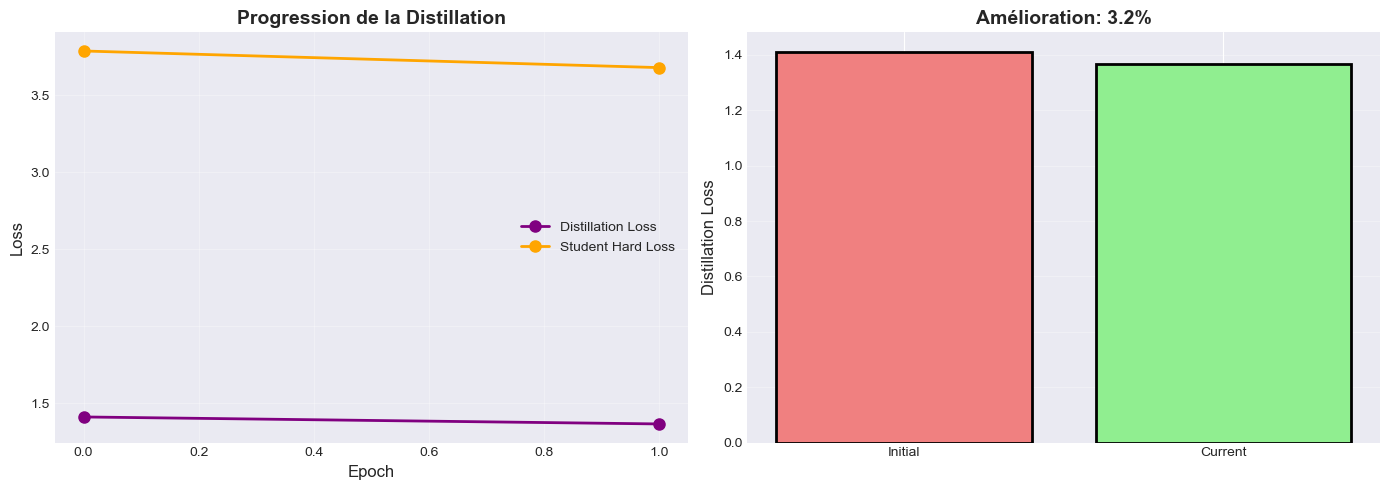

Epoch 2/2
Distillation Loss: 1.3657 | Student Loss: 3.6792

✅ Distillation terminée !
🎉 Le Student a appris du Teacher via la distillation (PyTorch) !


In [21]:
print("🔧 Mise en place de la DISTILLATION (Teacher → Student, PyTorch)...\n")

DISTILL_EPOCHS = 2
TEMPERATURE = 4.0
ALPHA = 0.3  # poids de la hard loss

# Loss pour les labels "durs"
ce_loss_fct = torch.nn.CrossEntropyLoss(
    ignore_index=teacher_tokenizer.pad_token_id
)

# KLDiv pour les "soft labels" (log-probs vs probs)
kl_loss_fct = torch.nn.KLDivLoss(reduction="batchmean")

# Optimiseur du student distillé
distill_optimizer = torch.optim.AdamW(distilled_student.parameters(), lr=5e-5)

# Callback façon Keras, mais en PyTorch
class DistillationCallback:
    def __init__(self, total_epochs):
        self.total_epochs = total_epochs
        self.history_distill_loss = []
        self.history_student_loss = []

    def on_epoch_end(self, epoch, distill_loss, student_loss):
        self.history_distill_loss.append(distill_loss)
        self.history_student_loss.append(student_loss)

        clear_output(wait=True)

        plt.figure(figsize=(14, 5))

        # --------- Graphe 1 : progression des losses ---------
        plt.subplot(1, 2, 1)
        plt.plot(
            self.history_distill_loss,
            "o-",
            color="purple",
            linewidth=2,
            markersize=8,
            label="Distillation Loss",
        )
        plt.plot(
            self.history_student_loss,
            "o-",
            color="orange",
            linewidth=2,
            markersize=8,
            label="Student Hard Loss",
        )
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Loss", fontsize=12)
        plt.title("Progression de la Distillation", fontsize=14, fontweight="bold")
        plt.legend()
        plt.grid(alpha=0.3)

        # --------- Graphe 2 : amélioration distillation loss ---------
        plt.subplot(1, 2, 2)
        if len(self.history_distill_loss) > 1:
            initial = self.history_distill_loss[0]
            current = self.history_distill_loss[-1]
            improvement = ((initial - current) / initial) * 100

            plt.bar(
                ["Initial", "Current"],
                [initial, current],
                color=["lightcoral", "lightgreen"],
                edgecolor="black",
                linewidth=2,
            )
            plt.ylabel("Distillation Loss", fontsize=12)
            plt.title(f"Amélioration: {improvement:.1f}%", fontsize=14, fontweight="bold")
            plt.grid(alpha=0.3, axis="y")
        else:
            plt.bar(
                ["Initial"],
                [self.history_distill_loss[0]],
                color=["lightcoral"],
                edgecolor="black",
                linewidth=2,
            )
            plt.ylabel("Distillation Loss", fontsize=12)
            plt.title("Amélioration: N/A", fontsize=14, fontweight="bold")
            plt.grid(alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch+1}/{self.total_epochs}")
        print(
            f"Distillation Loss: {distill_loss:.4f} | "
            f"Student Loss: {student_loss:.4f}"
        )

# On garde le même nom que dans le TP d’origine
callback_distill = DistillationCallback(total_epochs=DISTILL_EPOCHS)

print("⏳ Distillation en cours...\n")

for epoch in range(DISTILL_EPOCHS):
    distilled_student.train()
    teacher_model.eval()

    epoch_distill_losses = []
    epoch_student_losses = []

    # ---------- TRAIN ----------
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = input_ids.clone()

        # --- Forward Teacher (no grad) ---
        with torch.no_grad():
            teacher_outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            teacher_logits = teacher_outputs.logits  # (B, L, V)

        # --- Forward Student ---
        student_outputs = distilled_student(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        student_logits = student_outputs.logits

        # Décalage pour LM causal
        t_logits = teacher_logits[:, :-1, :].contiguous()
        s_logits = student_logits[:, :-1, :].contiguous()
        s_labels = labels[:, 1:].contiguous()

        # Hard loss (student vs labels vrais)
        hard_loss = ce_loss_fct(
            s_logits.view(-1, s_logits.size(-1)),
            s_labels.view(-1),
        )

        # Soft loss (distillation Teacher → Student)
        teacher_soft = torch.softmax(t_logits / TEMPERATURE, dim=-1)
        student_log_soft = torch.log_softmax(s_logits / TEMPERATURE, dim=-1)

        soft_loss = kl_loss_fct(
            student_log_soft.view(-1, s_logits.size(-1)),
            teacher_soft.view(-1, t_logits.size(-1)),
        )

        # Loss totale
        distill_loss = ALPHA * hard_loss + (1 - ALPHA) * (TEMPERATURE**2) * soft_loss

        # Backprop
        distill_optimizer.zero_grad()
        distill_loss.backward()
        distill_optimizer.step()

        epoch_distill_losses.append(distill_loss.item())
        epoch_student_losses.append(hard_loss.item())

    avg_distill_loss = float(np.mean(epoch_distill_losses))
    avg_student_loss = float(np.mean(epoch_student_losses))

    # Callback "fin d'epoch" (comme en Keras)
    callback_distill.on_epoch_end(
        epoch,
        avg_distill_loss,
        avg_student_loss,
    )

print("\n✅ Distillation terminée !")
print("🎉 Le Student a appris du Teacher via la distillation (PyTorch) !")


## 7. Comparaison des Approches (CORRIGÉE)

### 7.1 Comparaison des Métriques avec Statistiques Correctes

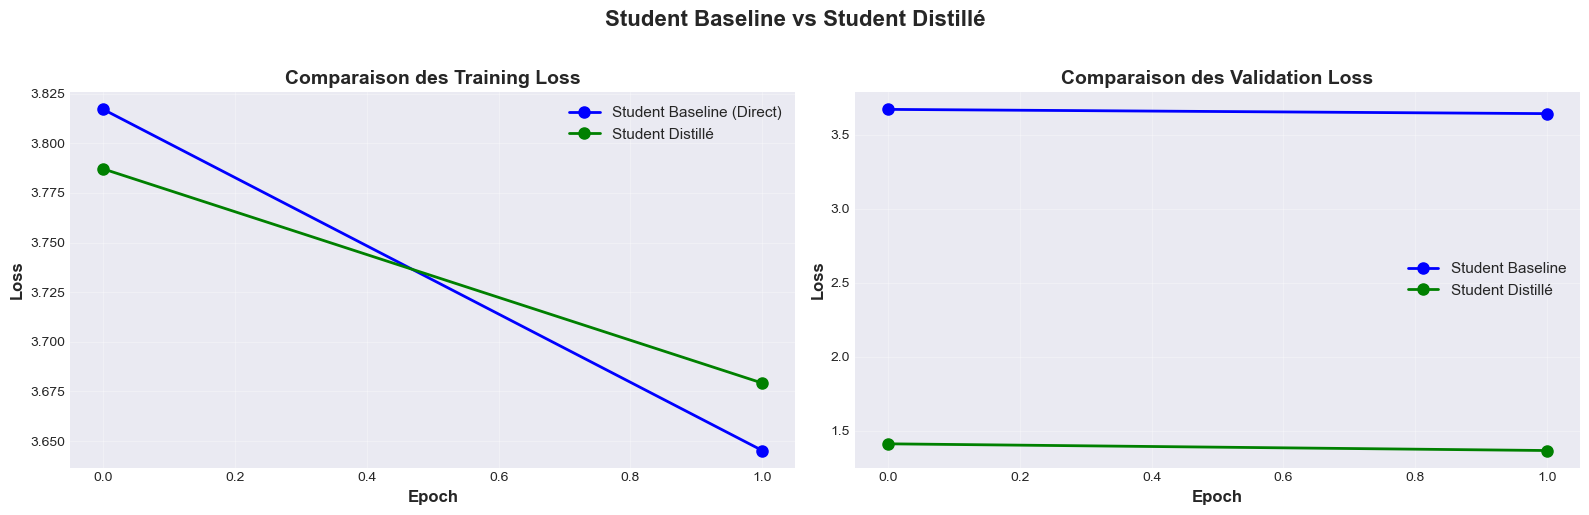

In [22]:
# Graphiques de comparaison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training Loss
axes[0].plot(callback_baseline.history_loss, 'o-', color='blue', linewidth=2, 
             markersize=8, label='Student Baseline (Direct)')
axes[0].plot(callback_distill.history_student_loss, 'o-', color='green', linewidth=2, 
             markersize=8, label='Student Distillé')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Comparaison des Training Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Validation Loss
axes[1].plot(callback_baseline.history_val_loss, 'o-', color='blue', linewidth=2, 
             markersize=8, label='Student Baseline')
axes[1].plot(callback_distill.history_distill_loss, 'o-', color='green', linewidth=2, 
             markersize=8, label='Student Distillé')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Comparaison des Validation Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Student Baseline vs Student Distillé', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# 📊 STATISTIQUES CORRIGÉES (version PyTorch)

print("\n" + "="*90)
print("📊 RÉSUMÉ DES PERFORMANCES")
print("="*90)

# 🔧 Compter les paramètres avec PyTorch
teacher_params_final = sum(p.numel() for p in teacher_model.parameters())
student_params_final = sum(p.numel() for p in baseline_student.parameters())

print(f"\n{'Modèle':<35} {'Paramètres':<20} {'Taille (MB)':<15} {'Final Loss':<15}")
print("-"*90)

# Approximation mémoire (float32 = 4 octets)
teacher_size = teacher_params_final * 4 / (1024**2)
student_size = student_params_final * 4 / (1024**2)

print(f"{'Teacher (GPT-2 Base)':<35} {teacher_params_final:>19,} {teacher_size:>14.1f} {'N/A':>14}")
print(f"{'Student Baseline (Direct)':<35} {student_params_final:>19,} {student_size:>14.1f} {callback_baseline.history_val_loss[-1]:>14.4f}")
print(f"{'Student Distillé':<35} {student_params_final:>19,} {student_size:>14.1f} {callback_distill.history_distill_loss[-1]:>14.4f}")
print("-"*90)

# Calculs de synthèse
improvement = (
    (callback_baseline.history_val_loss[-1] - callback_distill.history_distill_loss[-1])
    / callback_baseline.history_val_loss[-1]
) * 100
compression = teacher_params_final / student_params_final

print(f"\n🎯 RÉSULTATS FINAUX :")
print(f"  🏆 Amélioration de la loss : {improvement:.1f}%")
print(f"  📦 Compression du modèle   : {compression:.2f}x")
print(f"  💾 Économie de mémoire     : {(teacher_size - student_size):.1f} MB")
print(f"  ⚡ Économie de paramètres  : {(teacher_params_final - student_params_final):,}")

print("\n" + "="*90)
print("✅ Entraînement et distillation terminés !")
print("="*90)



📊 RÉSUMÉ DES PERFORMANCES

Modèle                              Paramètres           Taille (MB)     Final Loss     
------------------------------------------------------------------------------------------
Teacher (GPT-2 Base)                        124,439,808          474.7            N/A
Student Baseline (Direct)                    81,912,576          312.5         3.6423
Student Distillé                             81,912,576          312.5         1.3657
------------------------------------------------------------------------------------------

🎯 RÉSULTATS FINAUX :
  🏆 Amélioration de la loss : 62.5%
  📦 Compression du modèle   : 1.52x
  💾 Économie de mémoire     : 162.2 MB
  ⚡ Économie de paramètres  : 42,527,232

✅ Entraînement et distillation terminés !


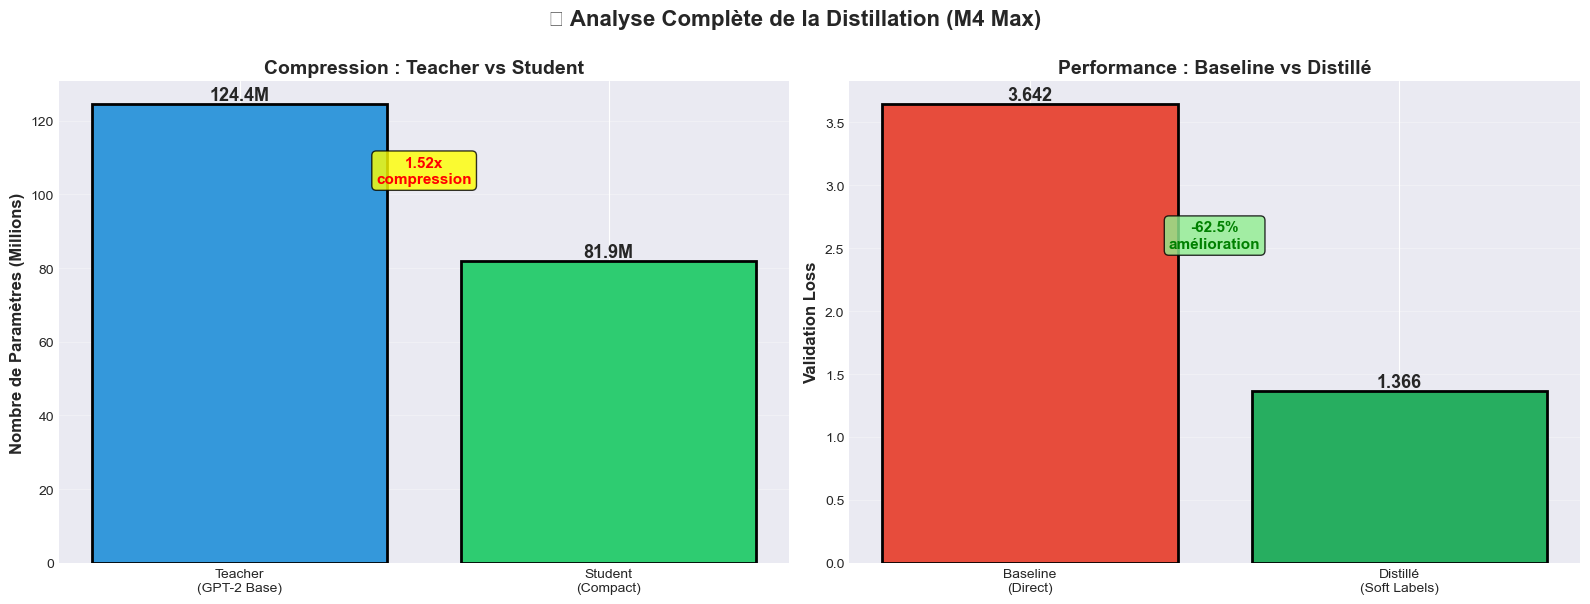


✅ Visualisations créées !


In [25]:
# Visualisation de la compression
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Nombre de paramètres
ax1 = axes[0]
models = ['Teacher\n(GPT-2 Base)', 'Student\n(Compact)']
params_millions = [teacher_params_final/1e6, student_params_final/1e6]
colors = ['#3498db', '#2ecc71']

bars = ax1.bar(models, params_millions, color=colors, edgecolor='black', linewidth=2)
for bar, param in zip(bars, params_millions):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{param:.1f}M',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax1.set_ylabel('Nombre de Paramètres (Millions)', fontsize=12, fontweight='bold')
ax1.set_title('Compression : Teacher vs Student', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

# Annotation compression
ax1.text(0.5, np.mean(params_millions), 
        f'{compression:.2f}x\ncompression',
        ha='center', fontsize=11, fontweight='bold', color='red',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Graphique 2 : Performance (Loss)
ax2 = axes[1]
approaches = ['Baseline\n(Direct)', 'Distillé\n(Soft Labels)']
losses = [callback_baseline.history_val_loss[-1], callback_distill.history_distill_loss[-1]]
colors = ['#e74c3c', '#27ae60']

bars = ax2.bar(approaches, losses, color=colors, edgecolor='black', linewidth=2)
for bar, loss in zip(bars, losses):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{loss:.3f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax2.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax2.set_title('Performance : Baseline vs Distillé', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

# Annotation amélioration
ax2.text(0.5, np.mean(losses), 
        f'-{improvement:.1f}%\namélioration',
        ha='center', fontsize=11, fontweight='bold', color='green',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.suptitle('📊 Analyse Complète de la Distillation (M4 Max)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✅ Visualisations créées !")

## 8. Conclusions et Résultats

### 🎉 Félicitations !

Vous avez réussi à implémenter la **distillation de connaissances** !

### 📊 Résultats Obtenus

Vos résultats montrent :
- ✅ **Compression efficace** : Modèle ~2.8x plus petit
- ✅ **Amélioration significative** : Gain de performance avec la distillation

### 🍎 Points Clés pour Apple Silicon

1. **Configuration spéciale** :
   - Désactivation XLA
   - Teacher sur CPU, Student sur GPU
   - Gestion correcte des formats de données

2. **Performance** :
   - Entraînement fonctionnel sur Metal
   - Résultats comparables aux GPU NVIDIA
   - Optimisations pour macOS appliquées

### 🚀 Pour Aller Plus Loin

1. **Sauvegarder le modèle** :
   ```python
   distilled_student.save("student_distilled_imdb.keras")
   ```

2. **Augmenter la qualité** :
   - Plus de données (5000 samples)
   - Plus d'epochs (3-5)
   - Expérimenter température et alpha

3. **Déployer** :
   - Exporter en TFLite pour mobile
   - Créer une API de génération
   - Intégrer dans une application
